In [1]:
import sys
import importlib.util
import importlib.machinery
from pathlib import Path
import cv2
import os
import numpy as np

%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def center_zoom(img: np.ndarray, zoom: float) -> np.ndarray:
    """
    Centered zoom (like torchvision CenterCrop but with zoom factor).
    
    Args:
        img: np.ndarray (H, W, C) or (H, W)
        zoom: Zoom factor (>1 zooms in, <1 zooms out)
    
    Returns:
        np.ndarray: Same size as input image, zoomed.
    """
    if zoom <= 0:
        raise ValueError("Zoom factor must be positive.")

    h, w = img.shape[:2]
    center_x, center_y = w / 2, h / 2

    if zoom == 1:
        return img.copy()

    if zoom > 1:
        # ---- Zoom In (Crop then Resize) ----
        new_w, new_h = int(w / zoom), int(h / zoom)
        x1 = int(center_x - new_w / 2)
        y1 = int(center_y - new_h / 2)
        x2 = x1 + new_w
        y2 = y1 + new_h
        cropped = img[y1:y2, x1:x2]
        zoomed = cv2.resize(cropped, (w, h), interpolation=cv2.INTER_LINEAR)

    else:
        # ---- Zoom Out (Shrink then Pad) ----
        new_w, new_h = int(w * zoom), int(h * zoom)
        resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_LINEAR)

        # Create black canvas same size as input
        zoomed = np.zeros_like(img)

        # Compute paste coordinates (centered)
        x1 = (w - new_w) // 2
        y1 = (h - new_h) // 2

        # Paste resized image in center
        zoomed[y1:y1 + new_h, x1:x1 + new_w] = resized

    return zoomed

def zoom_at(img, zoom=1, angle=0, coord=None):
    
    cy, cx = [ i/2 for i in img.shape[:-1] ] if coord is None else coord[::-1]
    
    rot_mat = cv2.getRotationMatrix2D((cx,cy), angle, zoom)
    result = cv2.warpAffine(img, rot_mat, img.shape[1::-1], flags=cv2.INTER_LINEAR)
    
    return result

In [3]:
def plot_multiple(image_paths, image_labels=None,nrow=1,figsize=None):
    if figsize is None:
        figsize=(ncol, nrow)
        
    ncol = int(np.ceil(len(image_paths)/nrow))
    print(ncol)
    fig, ax = plt.subplots(nrow,ncol, figsize=figsize)

    for id_image, image_path in enumerate(image_paths):
        if os.path.exists(image_path):
            img_now = cv2.cvtColor(cv2.imread(image_path),cv2.COLOR_BGR2RGB) 
        else:
            img_now = image_path

        if nrow>1:
            ax[id_image%nrow,id_image//nrow].imshow(img_now)
            ax[id_image%nrow,id_image//nrow].axis("off")
            if image_labels:
                ax[id_image%nrow,id_image//nrow].set_title(image_labels[id_image])
        else:
            ax[id_image].imshow(img_now)
            ax[id_image].axis("off")
            if image_labels:
                ax[id_image].set_title(image_labels[id_image])
   
    return fig,ax

In [4]:
# map package name → alternative path
ALT_MODULE_PATHS = {
    "face_detection": "/mnt/ssd/workspace/adi/vh_repos_byversion/face-detection/3-0-0/face-production-face-detection/face_detection"
}
class AltImportFinder(importlib.abc.MetaPathFinder):
    def find_spec(self, fullname, path, target=None):
        if fullname in ALT_MODULE_PATHS:
            alt_path = Path(ALT_MODULE_PATHS[fullname])
            init_file = alt_path / "__init__.py"
            if not init_file.exists():
                return None
            loader = importlib.machinery.SourceFileLoader(fullname, str(init_file))
            return importlib.util.spec_from_loader(fullname, loader, origin=str(init_file))
        return None

# install our custom finder at the front
finder = AltImportFinder()
if not any(isinstance(f, AltImportFinder) for f in sys.meta_path):
    sys.meta_path.insert(0, finder)

In [5]:
from face_detection import FaceDetection
fd = FaceDetection()

Model warm-up completed with 1 runs.
Model warm-up completed with 1 runs.
Model warm-up completed with 1 runs.


In [6]:
source_folder = "/mnt/ssd/workspace/adi/repos/vh_deepfake_trainer/datasets/deepfake/200k_live_face_dataset/live"
folder_swapped = {"mobilefaceswap":"/mnt/ssd/workspace/adi/repos/vh_deepfake_trainer/datasets/deepfake/200k_55plus/fake/mobilefaceswap",
                  "e4s":"/mnt/ssd/workspace/adi/repos/vh_deepfake_trainer/datasets/deepfake/200k_55plus/fake/e4s_20251103",
                  "reswapper":"/mnt/ssd/workspace/adi/repos/vh_deepfake_trainer/datasets/deepfake/200k_55plus/fake/reswapper",
                  "blendface":"/mnt/ssd/workspace/adi/repos/vh_deepfake_trainer/datasets/deepfake/200k_55plus/fake/blendface",
                  "uniface":"/mnt/ssd/workspace/adi/repos/vh_deepfake_trainer/datasets/deepfake/200k_55plus/fake/uniface"}

In [7]:
list_source_images = os.listdir(source_folder)
list_img_files = os.listdir(folder_swapped["mobilefaceswap"])
swapped_img_name = list_img_files[100]
source_img_name, target_img_name = swapped_img_name.split('.jpg')[0].split('_to_')
swapped_img_path = os.path.join(folder_swapped["mobilefaceswap"],swapped_img_name)
source_img_path = os.path.join(source_folder,[s for s in list_source_images if s.startswith(source_img_name)][0])
target_img_path = os.path.join(source_folder,[s for s in list_source_images if s.startswith(target_img_name)][0])

1
0.8
4


(<Figure size 600x400 with 4 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object))

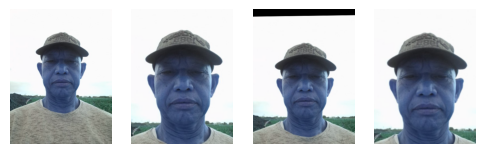

In [8]:
img = cv2.imread(source_img_path)
# get face detection result
dets, ang = fd.predict(img)
img_cropped_1 = fd.extract_face(img, dets, ang, task="face-iso", return_bbox=True, loose_factor = 1)
img_cropped_2 = fd.extract_face(img, dets, ang, task="face-iso", return_bbox=True, loose_factor = 0.8)
#img_cropped_3 = center_zoom(img_cropped_2, 1.5) # Zoom in back to ISO
img_cropped_3 = zoom_at(img_cropped_2, 1.3) # Zoom in back to ISO
#plt.imshow(img_cropped)
#print(img_cropped.shape)

plot_multiple([img,img_cropped_1,img_cropped_2,img_cropped_3],nrow=1,figsize=(6,4))

1
0.6
4


(<Figure size 600x400 with 4 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object))

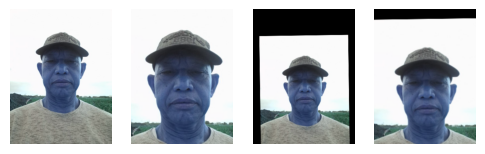

In [101]:
img = cv2.imread(source_img_path)
# get face detection result
dets, ang = fd.predict(img)
img_cropped_1 = fd.extract_face(img, dets, ang, task="face-iso", return_bbox=True, loose_factor = 1)
img_cropped_2 = fd.extract_face(img, dets, ang, task="face-iso", return_bbox=True, loose_factor = 0.6)
img_cropped_3 = center_zoom(img_cropped_2, 1.4) # Zoom in back to ISO
#plt.imshow(img_cropped)
#print(img_cropped.shape)

plot_multiple([img,img_cropped_1,img_cropped_2,img_cropped_3],nrow=1,figsize=(6,4))

0.8


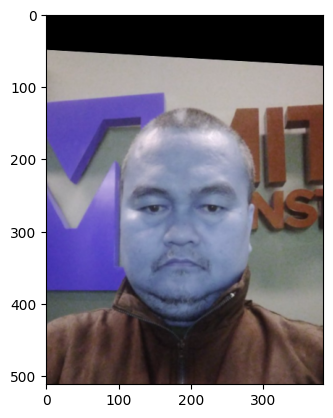

In [15]:
img = cv2.imread(source_img_path)
# get face detection result
dets, ang = fd.predict(img)
img_cropped = fd.extract_face(img, dets, ang, task="face-iso", return_bbox=True, loose_factor = 1/1.25)
plt.imshow(img_cropped)

In [6]:
img_cropped.shape

NameError: name 'img_cropped' is not defined

1


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 1 and the array at index 1 has size 3

1.25


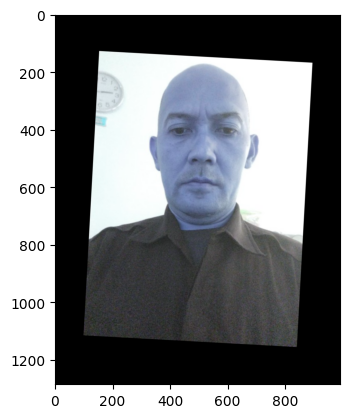

In [12]:
img = cv2.imread(source_img_path)
# get face detection result
dets, ang = fd.predict(img)
img_cropped = fd.extract_face(img, dets, ang, task="face-iso", return_bbox=True, loose_factor = 1.25)
plt.imshow(img_cropped)

    

1.75


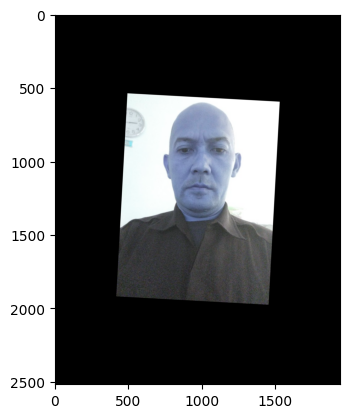

In [13]:
img = cv2.imread(source_img_path)
# get face detection result
dets, ang = fd.predict(img)
img_cropped = fd.extract_face(img, dets, ang, task="face-iso", return_bbox=True, loose_factor = 1.75)
plt.imshow(img_cropped)